#### The standard pattern is: 
x → self-attention → add & norm → FFN → add & norm, repeated across layers

#### Step-by-step build

1. Start with input embeddings

    - Your input should already be token embeddings plus positional encodings.
    - Shape is usually (batch_size, seq_len, d_model).

2. Self-attention block

    - Use query = key = value = x.
    - Apply a padding mask if needed.
    - Output has the same shape as input.

3. First residual + norm

    - Add the attention output to the original input.
    - Apply LayerNorm.

4. Feed-forward block

    - Use a position-wise MLP, for example:
        - Linear(d_model -> dff)
        - ReLU/GELU
        - Linear(dff -> d_model)
    - This is applied independently at each sequence position.

5. Second residual + norm

    - Add FFN output to the attention output.
    - Apply LayerNorm again.

6. Repeat with stacking

    - Put several identical encoder layers in a loop or module list.
    - Each layer takes the previous layer’s output as input.

In [17]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_head, d_ff, dropout=0.1):
        super(EncoderLayer, self).__init__()
        self.self_attn = nn.MultiheadAttention(d_model, num_heads=num_head, dropout=dropout, batch_first=True)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, mask=None):
        #self attention
        attn_output, _ = self.self_attn(x, x, x, key_padding_mask=mask, need_weights=False)
        x = self.norm1(x + self.dropout(attn_output))

        #feed forward network
        ffn_output = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_output))
        return x

In [15]:
class Encoder(nn.Module):
    def __init__(self, num_layers, d_model, num_head, d_ff, dropout=0.1):
        super(Encoder, self).__init__()

        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_head, d_ff, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask=None, return_all_layers=False):
        layer_outputs = []

        for layer in self.layers:
            x = layer(x, mask)
            if return_all_layers:
                layer_outputs.append(x)

        if return_all_layers:
            return x, layer_outputs
        return x

| Feature | `for _ in range(num_layers)` | `for layer in self.layers` |
|---------|-------------------------------|---------------------------|
| Location | `__init__` function | `forward` function |
| When it runs | Once, when the model is born | Many times, whenever data is fed in |
| Purpose | To create and store the weights/architecture | To compute and transform the data |
| What it iterates over | A raw number (e.g., 0 to 5) | The actual PyTorch layer objects built by the first loop |

In [18]:
# -------------------------------------------------
# Visualization function
# -------------------------------------------------
def visualize_encoder_outputs(layer_outputs):
    """
    layer_outputs: list of tensors
                   each tensor shape = (batch_size, seq_len, d_model)
    Shows one heatmap per encoder layer for the first sample in batch.
    """

    num_layers = len(layer_outputs)

    plt.figure(figsize=(12, 3 * num_layers))

    for i, out in enumerate(layer_outputs):
        # take first batch item
        data = out[0].detach().cpu().numpy()   # shape: (seq_len, d_model)

        plt.subplot(num_layers, 1, i + 1)
        plt.imshow(data, aspect='auto', cmap='viridis')
        plt.colorbar()
        plt.title(f"Encoder Layer {i+1} Output")
        plt.xlabel("Embedding Dimension")
        plt.ylabel("Sequence Position")

    plt.tight_layout()
    plt.show()

In [22]:
# Hyperparameters
BATCH_SIZE = 32
SEQ_LEN = 100       # e.g., 100 words in a sentence
D_MODEL = 512       # Embedding dimension
NUM_HEADS = 8       # Number of attention heads (D_MODEL must be divisible by NUM_HEADS)
D_FF = 2048         # Feed-forward hidden dimension
NUM_LAYERS = 6      # Classic standard from the original paper
DROPOUT = 0.1

    # batch_size = 2
    # seq_len = 6
    # d_model = 16
    # num_head = 4
    # d_ff = 64
    # num_layers = 3

encoder = EncoderLayer(d_model=D_MODEL, num_head=NUM_HEADS, d_ff=D_FF, dropout=DROPOUT)


dummy_input = torch.randn(BATCH_SIZE, SEQ_LEN, D_MODEL)  # (batch_size, seq_len, d_model)


output = encoder(dummy_input)

print(f"Input shape:  {dummy_input.shape}")
print(f"Output shape: {output.shape}")  # Should be (BATCH_SIZE, SEQ_LEN, D_MODEL)


Input shape:  torch.Size([32, 100, 512])
Output shape: torch.Size([32, 100, 512])


##### 32 - Batch
##### 100 - seq length
##### 512 - Dimension

Final output shape: torch.Size([32, 100, 512])
Layer 1 output shape: torch.Size([32, 100, 512])
Layer 2 output shape: torch.Size([32, 100, 512])
Layer 3 output shape: torch.Size([32, 100, 512])
Layer 4 output shape: torch.Size([32, 100, 512])
Layer 5 output shape: torch.Size([32, 100, 512])
Layer 6 output shape: torch.Size([32, 100, 512])


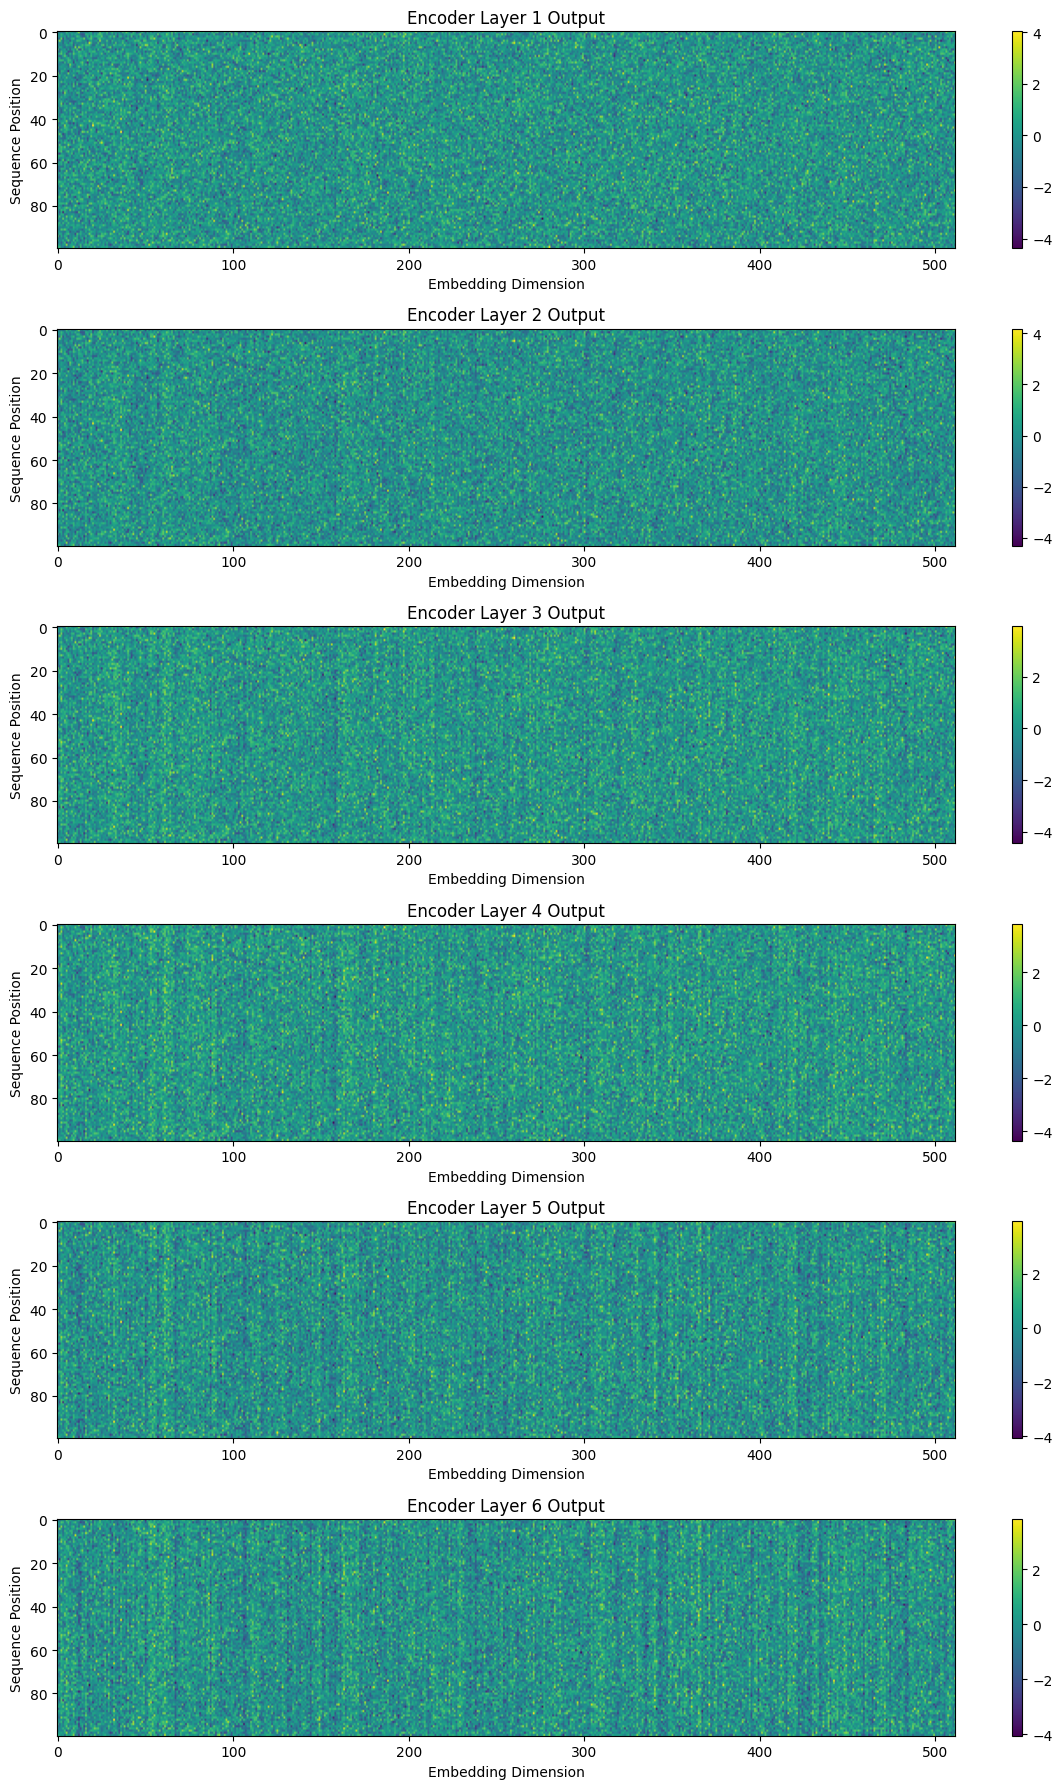

In [20]:
multi_encoder = Encoder(num_layers=NUM_LAYERS, d_model=D_MODEL, num_head=NUM_HEADS, d_ff=D_FF, dropout=DROPOUT)


final_output, all_layer_outputs = multi_encoder(dummy_input, return_all_layers=True)

print("Final output shape:", final_output.shape)
for i, out in enumerate(all_layer_outputs):
    print(f"Layer {i+1} output shape:", out.shape)

visualize_encoder_outputs(all_layer_outputs)


#### Per Head Visualization

Final output shape: torch.Size([2, 6, 16])
Layer 1 attention shape: torch.Size([2, 4, 6, 6])
Layer 2 attention shape: torch.Size([2, 4, 6, 6])
Layer 3 attention shape: torch.Size([2, 4, 6, 6])


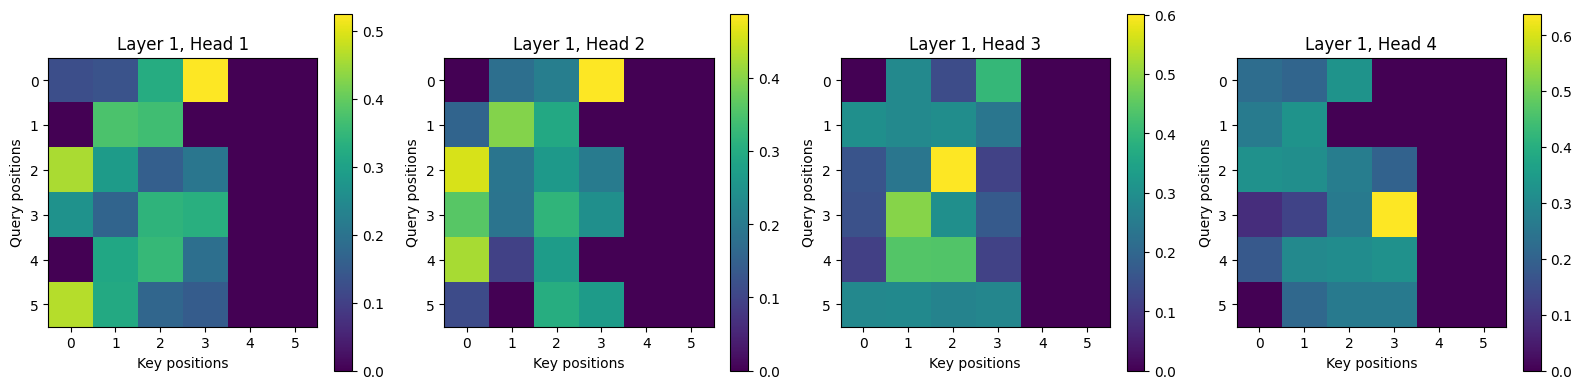

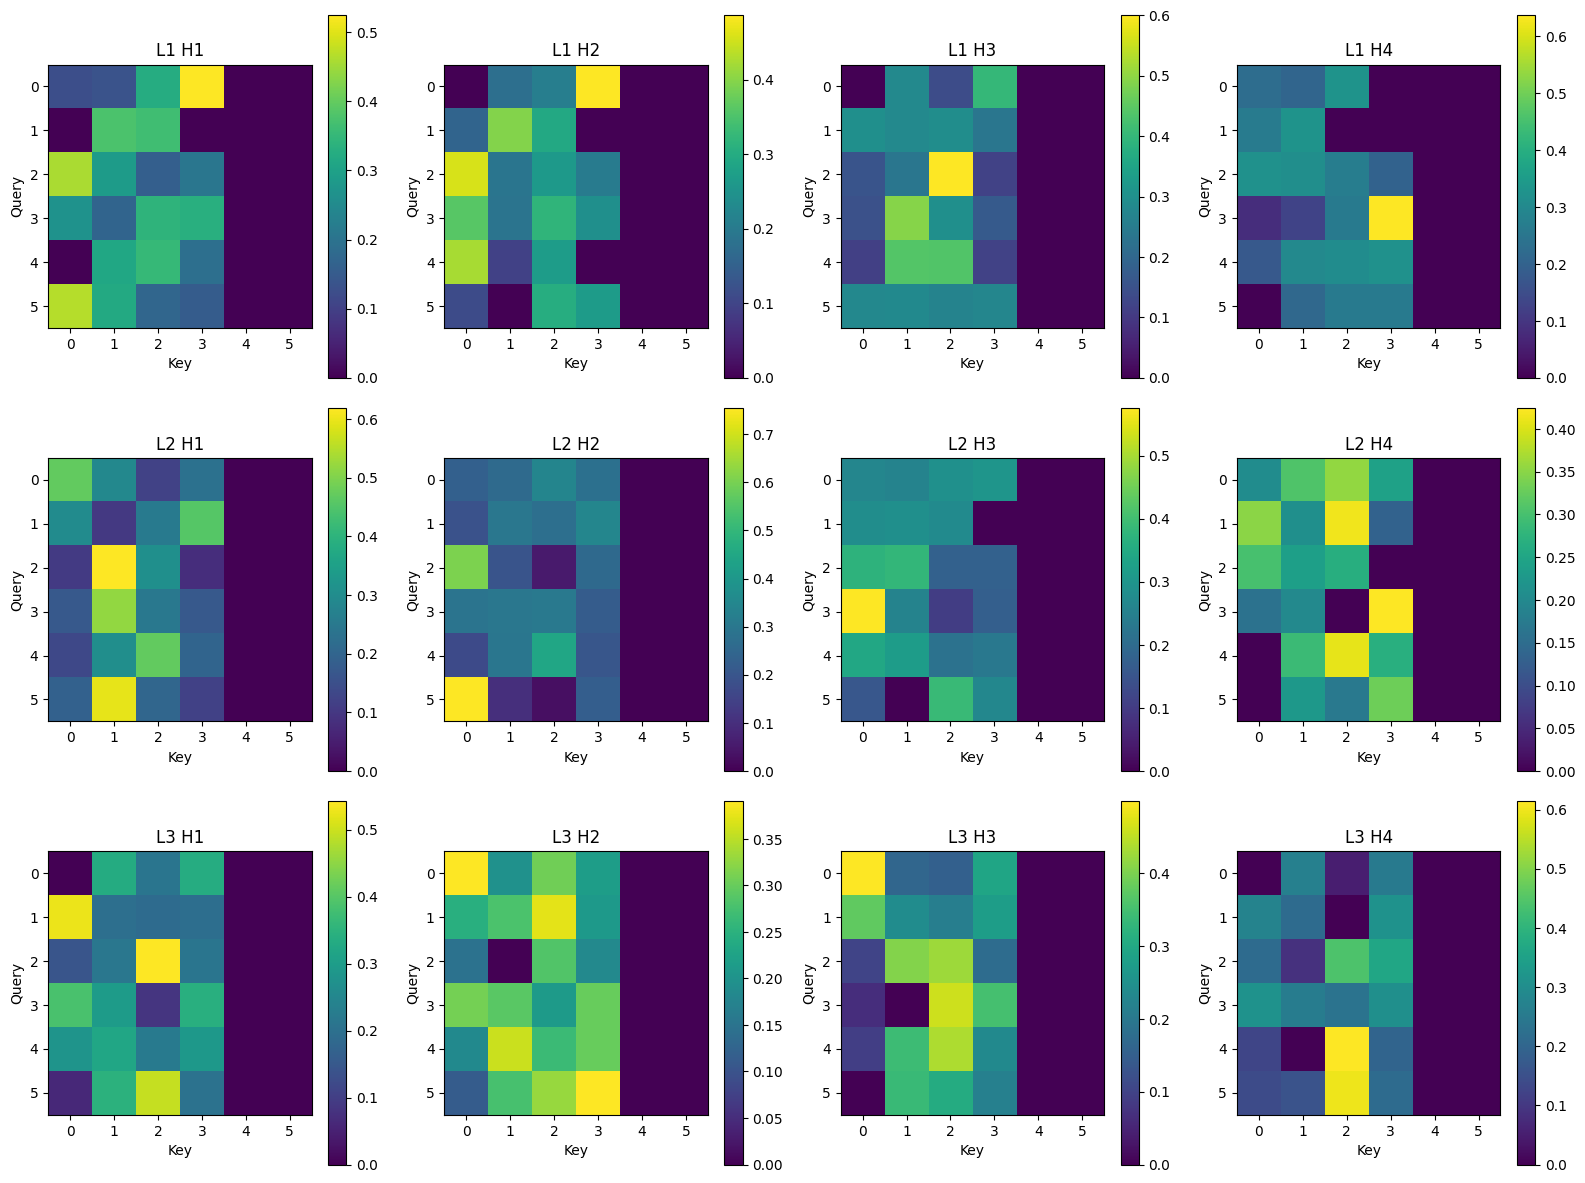

In [23]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# -------------------------------------------------
# Encoder Layer with per-head attention output
# -------------------------------------------------
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_head, d_ff, dropout=0.1):
        super(EncoderLayer, self).__init__()

        self.self_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_head,
            dropout=dropout,
            batch_first=True
        )

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None, return_attn=False):
        if return_attn:
            attn_output, attn_weights = self.self_attn(
                x, x, x,
                key_padding_mask=mask,
                need_weights=True,
                average_attn_weights=False
            )
        else:
            attn_output, attn_weights = self.self_attn(
                x, x, x,
                key_padding_mask=mask,
                need_weights=False
            )

        x = self.norm1(x + self.dropout(attn_output))

        ffn_output = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_output))

        if return_attn:
            return x, attn_weights
        return x


# -------------------------------------------------
# Full Transformer Encoder
# -------------------------------------------------
class TransformerEncoder(nn.Module):
    def __init__(self, num_layers, d_model, num_head, d_ff, dropout=0.1):
        super(TransformerEncoder, self).__init__()

        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_head, d_ff, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask=None, return_all_layers=False, return_attn=False):
        layer_outputs = []
        all_attn_weights = []

        for layer in self.layers:
            if return_attn:
                x, attn_weights = layer(x, mask=mask, return_attn=True)
                all_attn_weights.append(attn_weights)
            else:
                x = layer(x, mask=mask, return_attn=False)

            if return_all_layers:
                layer_outputs.append(x)

        outputs = [x]

        if return_all_layers:
            outputs.append(layer_outputs)

        if return_attn:
            outputs.append(all_attn_weights)

        if len(outputs) == 1:
            return outputs[0]
        return tuple(outputs)


# -------------------------------------------------
# Visualize per-head attention
# -------------------------------------------------
def visualize_attention_heads(attn_weights, layer_idx=0, batch_idx=0):
    """
    attn_weights: list of attention tensors from all layers
    Each element shape = (batch_size, num_heads, seq_len, seq_len)

    layer_idx: which encoder layer to visualize
    batch_idx: which batch sample to visualize
    """

    layer_attn = attn_weights[layer_idx][batch_idx].detach().cpu()
    num_heads = layer_attn.shape[0]

    plt.figure(figsize=(4 * num_heads, 4))

    for h in range(num_heads):
        plt.subplot(1, num_heads, h + 1)
        plt.imshow(layer_attn[h], cmap="viridis")
        plt.colorbar()
        plt.title(f"Layer {layer_idx+1}, Head {h+1}")
        plt.xlabel("Key positions")
        plt.ylabel("Query positions")

    plt.tight_layout()
    plt.show()


# -------------------------------------------------
# Visualize all layers and all heads
# -------------------------------------------------
def visualize_all_layers_all_heads(attn_weights, batch_idx=0):
    """
    Shows attention maps for every head in every layer.
    """
    num_layers = len(attn_weights)
    num_heads = attn_weights[0].shape[1]

    plt.figure(figsize=(4 * num_heads, 4 * num_layers))

    for l in range(num_layers):
        layer_attn = attn_weights[l][batch_idx].detach().cpu()  # (num_heads, seq_len, seq_len)

        for h in range(num_heads):
            plt.subplot(num_layers, num_heads, l * num_heads + h + 1)
            plt.imshow(layer_attn[h], cmap="viridis")
            plt.colorbar()
            plt.title(f"L{l+1} H{h+1}")
            plt.xlabel("Key")
            plt.ylabel("Query")

    plt.tight_layout()
    plt.show()


# -------------------------------------------------
# Test run
# -------------------------------------------------
if __name__ == "__main__":
    batch_size = 2
    seq_len = 6
    d_model = 16
    num_head = 4
    d_ff = 64
    num_layers = 3

    x = torch.randn(batch_size, seq_len, d_model)

    mask = torch.tensor([
        [False, False, False, False, True, True],
        [False, False, False, True, True, True]
    ])

    encoder = TransformerEncoder(
        num_layers=num_layers,
        d_model=d_model,
        num_head=num_head,
        d_ff=d_ff,
        dropout=0.1
    )

    final_output, layer_outputs, all_attn_weights = encoder(
        x,
        mask=mask,
        return_all_layers=True,
        return_attn=True
    )

    print("Final output shape:", final_output.shape)

    for i, attn in enumerate(all_attn_weights):
        print(f"Layer {i+1} attention shape: {attn.shape}")
        # expected: (batch_size, num_heads, seq_len, seq_len)

    # Visualize one layer
    visualize_attention_heads(all_attn_weights, layer_idx=0, batch_idx=0)

    # Visualize all layers
    visualize_all_layers_all_heads(all_attn_weights, batch_idx=0)